# Genetic Algorithm 遗传算法

## 本 Notebook 的教学目标

1. 在经典 TSP 场景下理解该算法的工作机制。
2. 完成一个从零实现版本，而不是只调用现成库。
3. 通过路径图、收敛曲线、统计结果观察算法行为。
4. 为下个月授课准备可直接展示的实验材料。

## 为什么选 TSP

遗传算法放在 TSP 上非常适合教学，因为“路径编码”“交叉”“变异”“种群演化”都可以配合路径图和曲线图一起讲。

TSP 的优点是：**结果是可视化路径，过程也是可视化路径**。因此它非常适合课堂讲解组合优化算法。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque

# 统一图表风格，保证不同 Notebook 的视觉体验一致。
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# 为了让路径图更直观，这里统一生成二维城市坐标。

def make_cities(n_cities=20, seed=7):
    rng = np.random.default_rng(seed)
    return rng.uniform(0, 100, size=(n_cities, 2))


def pairwise_distances(cities):
    diff = cities[:, None, :] - cities[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def route_length(route, distance_matrix):
    rolled = np.roll(route, -1)
    return float(distance_matrix[route, rolled].sum())


def plot_route(cities, route, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    ordered = cities[route]
    closed = np.vstack([ordered, ordered[0]])
    ax.plot(closed[:, 0], closed[:, 1], '-o', color='#1f77b4', lw=2, ms=6)
    for idx, (x, y) in enumerate(cities):
        ax.text(x + 1, y + 1, str(idx), fontsize=10)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    return ax


def two_opt_swap(route, i, j):
    new_route = route.copy()
    new_route[i:j] = route[i:j][::-1]
    return new_route


def random_route(rng, n_cities):
    return rng.permutation(n_cities)


def summarize_runs(scores):
    return pd.Series({
        'best': float(np.min(scores)),
        'mean': float(np.mean(scores)),
        'worst': float(np.max(scores)),
        'std': float(np.std(scores)),
    })


# 固定城市坐标，保证不同算法 Notebook 之间有可比性。
cities = make_cities(n_cities=20, seed=11)
distance_matrix = pairwise_distances(cities)

## 算法直觉

核心思想：维护一个种群，通过选择、交叉、变异不断产生新个体，并保留其中表现更好的路径结构。

在讲课时，可以把这个算法与“纯贪心”或“纯随机搜索”对照起来讲，学生更容易抓住重点。

In [2]:
def route_length_fitness(route, distance_matrix):
    return 1.0 / route_length(route, distance_matrix)


def ordered_crossover(parent_a, parent_b, rng):
    # OX 交叉可以保留路径片段，同时保证后代仍然是合法排列。
    n = len(parent_a)
    start, end = sorted(rng.choice(n, size=2, replace=False))
    child = -np.ones(n, dtype=int)
    child[start:end] = parent_a[start:end]

    fill_values = [city for city in parent_b if city not in child]
    fill_positions = [idx for idx in range(n) if child[idx] == -1]
    for idx, city in zip(fill_positions, fill_values):
        child[idx] = city
    return child


def mutate(route, rng, mutation_rate=0.15):
    route = route.copy()
    if rng.random() < mutation_rate:
        i, j = rng.choice(len(route), size=2, replace=False)
        route[i], route[j] = route[j], route[i]
    return route


def tournament_select(population, scores, rng, k=4):
    contenders = rng.choice(len(population), size=k, replace=False)
    best_idx = contenders[np.argmin(scores[contenders])]
    return population[best_idx]


def genetic_algorithm(distance_matrix, population_size=80, n_generations=150, mutation_rate=0.15, elite_size=6, seed=0):
    rng = np.random.default_rng(seed)
    n_cities = len(distance_matrix)
    population = np.array([random_route(rng, n_cities) for _ in range(population_size)])
    scores = np.array([route_length(route, distance_matrix) for route in population])

    best_lengths = [float(scores.min())]
    mean_lengths = [float(scores.mean())]
    snapshots = [(0, population[np.argmin(scores)].copy())]

    for generation in range(1, n_generations + 1):
        elite_indices = np.argsort(scores)[:elite_size]
        new_population = [population[idx].copy() for idx in elite_indices]

        # 除了精英保留外，其余个体由选择、交叉、变异共同产生。
        while len(new_population) < population_size:
            parent_a = tournament_select(population, scores, rng)
            parent_b = tournament_select(population, scores, rng)
            child = ordered_crossover(parent_a, parent_b, rng)
            child = mutate(child, rng, mutation_rate=mutation_rate)
            new_population.append(child)

        population = np.array(new_population)
        scores = np.array([route_length(route, distance_matrix) for route in population])
        best_lengths.append(float(scores.min()))
        mean_lengths.append(float(scores.mean()))

        if generation in {1, 10, 30, 60, 100, 150}:
            snapshots.append((generation, population[np.argmin(scores)].copy()))

    best_idx = int(np.argmin(scores))
    return {
        'best_route': population[best_idx],
        'best_length': float(scores[best_idx]),
        'best_lengths': np.array(best_lengths),
        'mean_lengths': np.array(mean_lengths),
        'snapshots': snapshots,
        'final_population_scores': scores,
    }

## 单次实验演示

下面先做一次完整实验。建议课堂上先关注：

1. 初始路径和最终路径差别有多大。
2. 收敛过程中是否存在明显跳跃。
3. 算法是否会在早期快速改进、后期缓慢收敛。

best route length: 415.865


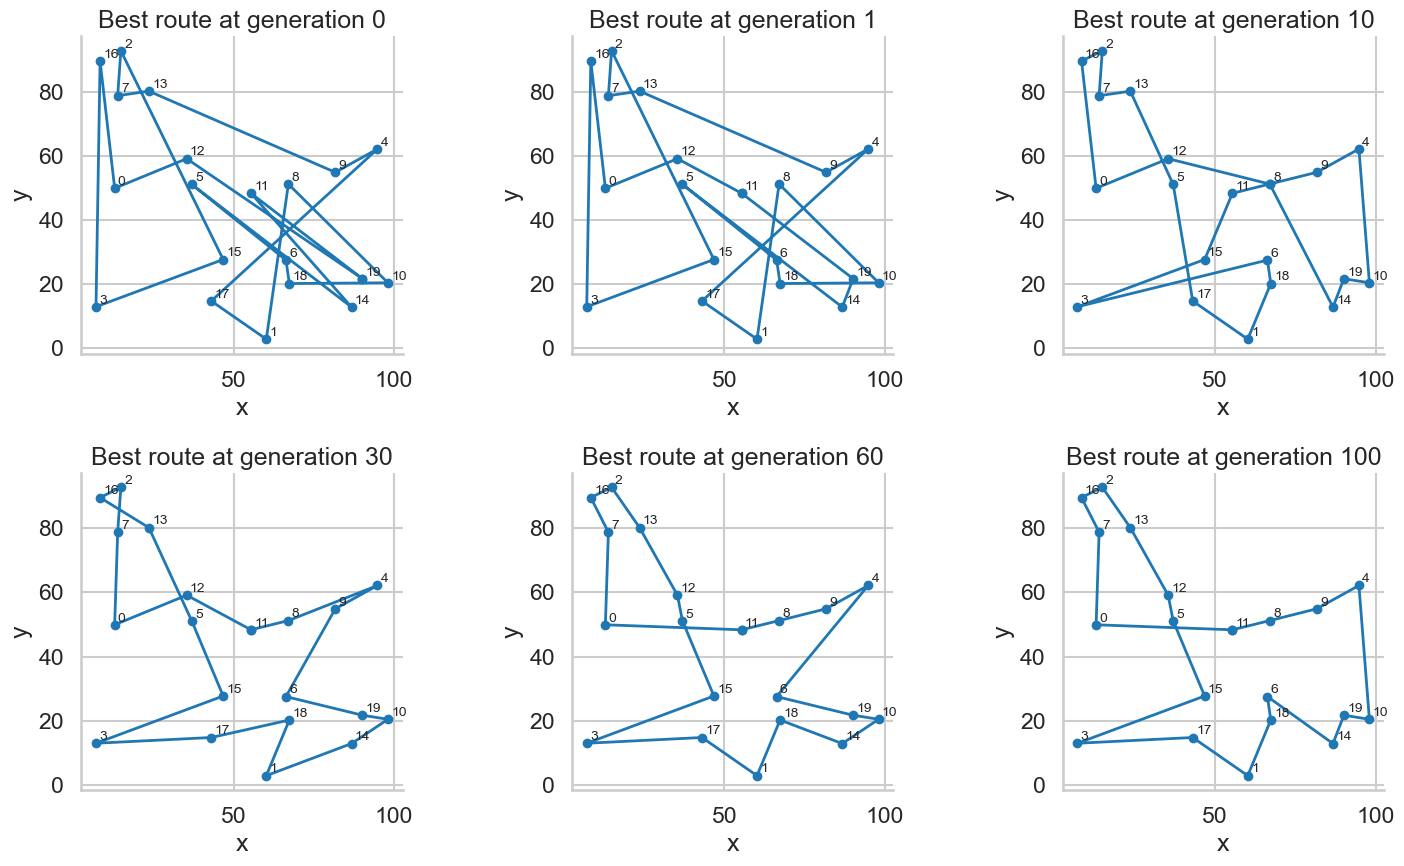

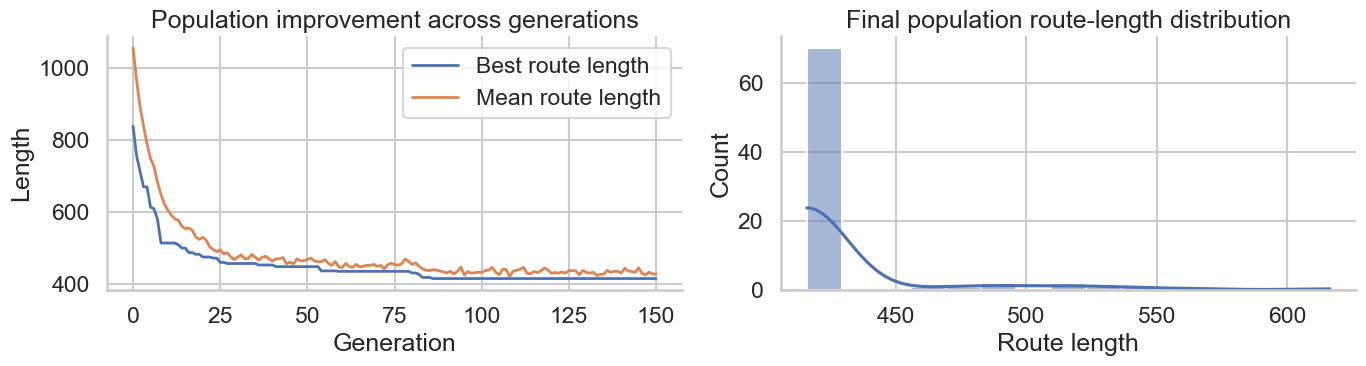

<Figure size 700x700 with 0 Axes>

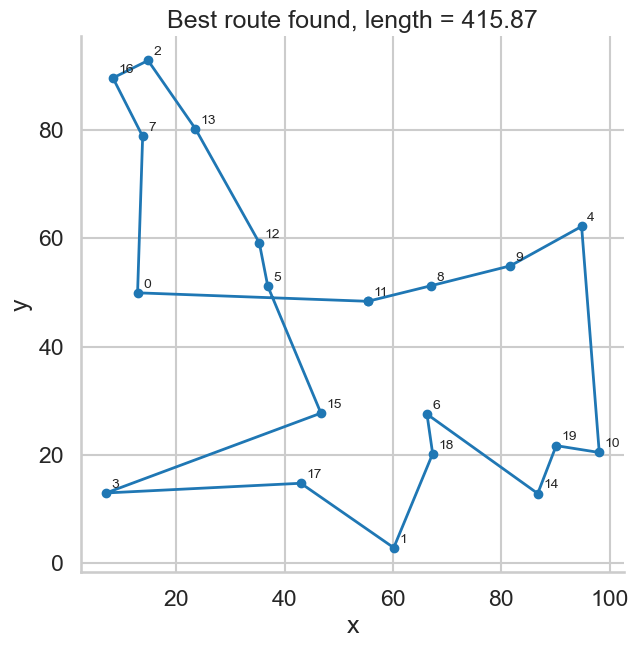

In [3]:
ga_result = genetic_algorithm(distance_matrix, seed=2)
print('best route length:', round(ga_result['best_length'], 3))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (generation, route) in zip(axes.ravel(), ga_result['snapshots']):
    plot_route(cities, route, f'Best route at generation {generation}', ax=ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ga_result['best_lengths'], lw=2, label='Best route length')
axes[0].plot(ga_result['mean_lengths'], lw=2, label='Mean route length')
axes[0].set_title('Population improvement across generations')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Length')
axes[0].legend()

sns.histplot(ga_result['final_population_scores'], bins=15, kde=True, ax=axes[1])
axes[1].set_title('Final population route-length distribution')
axes[1].set_xlabel('Route length')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plot_route(cities, ga_result['best_route'], f'Best route found, length = {ga_result["best_length"]:.2f}')
plt.show()

## 多次运行与参数分析

组合优化算法往往带有随机性，因此只看一次结果不够。这里用多次实验和参数敏感性分析来说明算法的稳定性与可调节性。

,Genetic Algorithm statistics
best,381.481754
mean,425.238273
worst,460.130202
std,19.006102


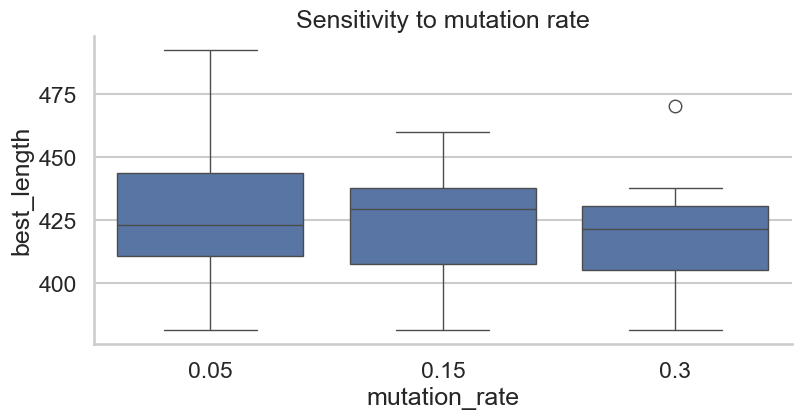

In [4]:
run_scores = [genetic_algorithm(distance_matrix, seed=seed)['best_length'] for seed in range(20)]
display(summarize_runs(run_scores).to_frame(name='Genetic Algorithm statistics'))

mutation_rates = [0.05, 0.15, 0.3]
records = []
for mutation_rate in mutation_rates:
    for seed in range(10):
        best_length = genetic_algorithm(distance_matrix, mutation_rate=mutation_rate, seed=seed)['best_length']
        records.append({'mutation_rate': mutation_rate, 'best_length': best_length})

param_df = pd.DataFrame(records)
plt.figure(figsize=(9, 4))
sns.boxplot(data=param_df, x='mutation_rate', y='best_length')
plt.title('Sensitivity to mutation rate')
plt.show()

## 课堂总结

讲这一类 TSP 实验时，可以让学生反复回答三个问题：

1. 新路径是怎样产生的。
2. 更差的路径何时会被接受，或为什么永远不被接受。
3. 算法如何在“探索新结构”和“保留好结构”之间权衡。